In [1]:
import pandas as pd
import seaborn as sns
import path_config
sns.set_theme() 

In [5]:
from lib.utils_plotting import print_avg_results, results_file, get_mae

results,results_w_regions = results_file("test", selected_months=[3,6,9,12])
results_val, results_w_regions_val = results_file("val", selected_months=[3,6,9,12])
	
from lib.utils_plotting import convex_ensemble, oracle_ensemble, oracle_ensemble_disagreement
for m1, m2 in [("prithvi_pretrained_crops_cathls_conv3d_1.0", "shallow_transformer_pixels_1.0")]:
	base_methods = [m1, m2]

	out_key = f"Ensemble {', '.join(base_methods)}"
	models_dbg = convex_ensemble(
		base_methods,
		results_w_regions_val,
		results_w_regions,
		out_name=out_key,
		region_col='NA_L1NAME',
	)

	# Oracle: optimal weights on test ground truth (upper bound for region ensemble)
	oracle_key = f"Oracle {', '.join(base_methods)}"
	oracle_ensemble(
		base_methods,
		results_w_regions,
		out_name=oracle_key,
		region_col='NA_L1NAME',
	)

	# Oracle: disagreement-conditioned weights on test ground truth
	disagree_key = f"Oracle-Disagree {', '.join(base_methods)}"
	oracle_ensemble_disagreement(
		base_methods,
		results_w_regions,
		out_name=disagree_key,
	)

results_mae = {"HLStile": [], "Date": [], "MAE": [], "Method": [], "SiteID": []}
for tile, siteid in results_w_regions["shallow_transformer_pixels_1.0_test"][["HLStile", "SiteID"]].drop_duplicates().values:
    for key in results_w_regions.keys(): 
        results_mae = get_mae(results_w_regions[key], tile, siteid, results_mae, key)

results_mae_df = pd.DataFrame(results_mae)

Disagreement oracle (10 bins):
   Bin        Disagree range  N pixels  w(prithvi_pretrai)  w(shallow_transfo)
     0       0.1 -      2.3         4056  0.407  0.593
     1       2.3 -      3.3         4056  0.409  0.591
     2       3.3 -      4.3         4056  0.356  0.644
     3       4.3 -      5.4         4056  0.394  0.606
     4       5.4 -      6.5         4056  0.448  0.552
     5       6.5 -      7.9         4056  0.399  0.601
     6       7.9 -      9.6         4056  0.456  0.544
     7       9.6 -     12.2         4056  0.466  0.534
     8      12.2 -     17.1         4056  0.474  0.526
     9      17.1 -    199.2         4057  0.643  0.357


## A- Overview of methods' results

1- The Shallow Temporal only Transformer from prior work performs the best. 

2- The Shallow Temporal model trained on our data performs better than prior work data. 

3- Pretraining improves the performance of Prithvi. 

In [7]:
methods_to_print = ["shallow_transformer_pixels_1.0_test", 
                    "prithvi_pretrained_crops_conv3d_1.0_test", 
                    "prithvi_pretrained_multiscale_crops_conv3d_1.0_test",
                    "prithvi_pretrained_crops_cathls_conv3d_1.0_test",
                    "shallow_transformer_pixels_priorwork_data_test"]
avg_results = print_avg_results(methods_to_print, results_mae_df)

                                                        G     M     S     D  Mean
Method                                                                           
shallow_transformer_pixels_1.0_test                  14.5  13.6  18.7  17.5  16.1
prithvi_pretrained_crops_conv3d_1.0_test             14.4  13.4  19.0  17.8  16.1
prithvi_pretrained_multiscale_crops_conv3d_1.0_test  13.9  13.2  19.1  17.8  16.0
prithvi_pretrained_crops_cathls_conv3d_1.0_test      14.1  13.3  18.9  17.5  16.0
shallow_transformer_pixels_priorwork_data_test       13.3  10.7  16.4  15.3  14.0


## C- Does Prithvi have any advantges? 

We split performance per eco region. We note that: 

1- Prithvi performs substantially better on the North American Deserts region. 

2- This improvements disappears when the pretraining is absent highlighting its significance. 

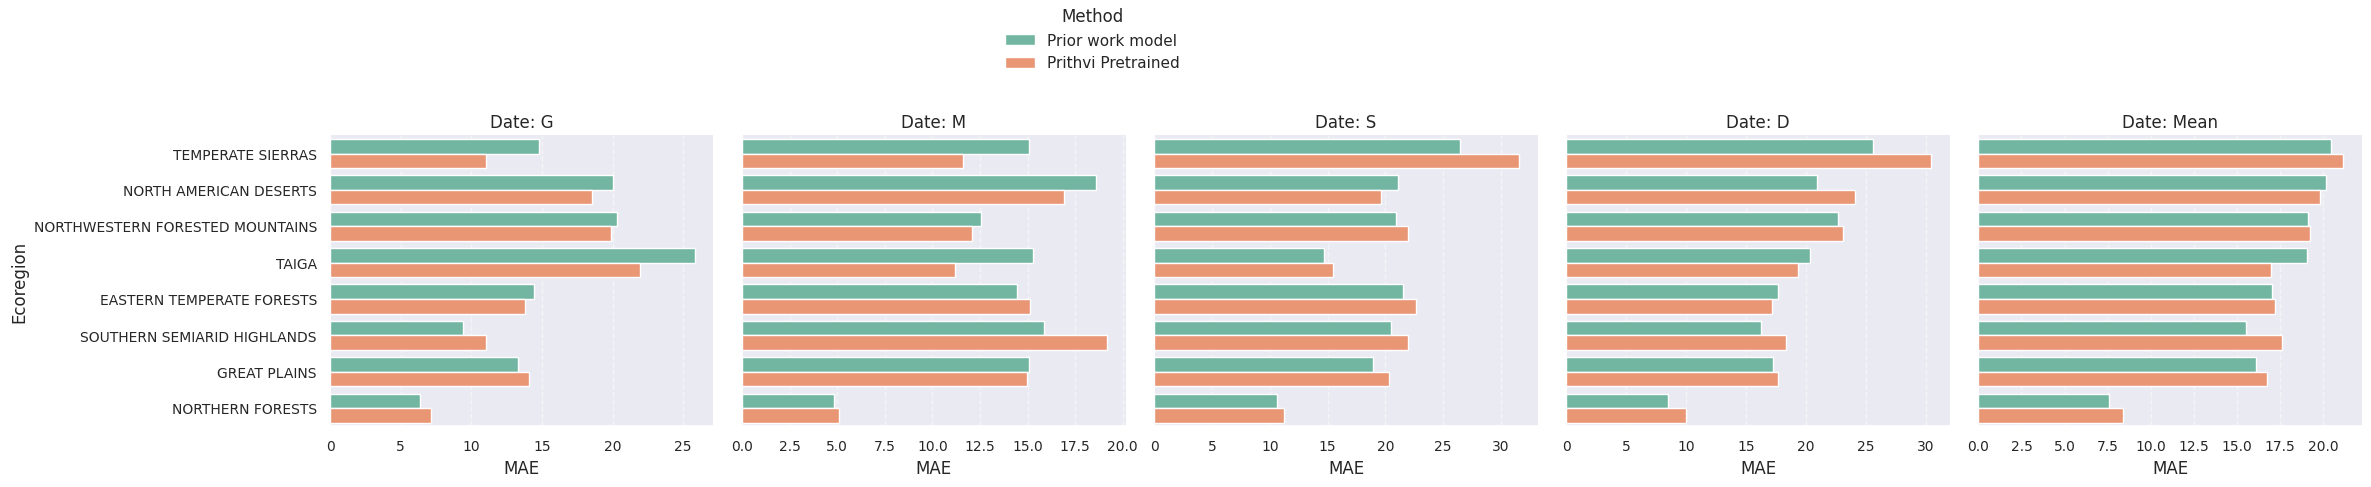

In [22]:
from lib.utils_plotting import plot_methods_regions_split

results_mae_df_ = results_mae_df.copy()
results_mae_df_["Method"] = results_mae_df_["Method"].replace("shallow_transformer_pixels_1.0_test", "Prior work model")
results_mae_df_["Method"] = results_mae_df_["Method"].replace("prithvi_pretrained_multiscale_crops_conv3d_1.0_test", "Prithvi Pretrained")

plot_methods_regions_split(results_mae_df_, 
                            geo_path=path_config.get_data_geojson(),
                            eco_path="useco1/NA_CEC_Eco_Level1.shp",
                            methods=["Prior work model", "Prithvi Pretrained"],
                         )

### D- Can we make use of this improved performance? 

We propose to use an Ensemble model that combines prior work shallow transformer and Prithvi outputs. Observe below that ensemble model significantly improves average performance, especially on north american deserts region. 

In [9]:
methods_to_print = ["prithvi_pretrained_crops_cathls_conv3d_1.0_test", 
                    "shallow_transformer_pixels_1.0_test", 
                    "Ensemble prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0", 
                    "Oracle prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0",
                    "Oracle-Disagree prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0",
                    "shallow_transformer_pixels_priorwork_data_test"]
avg_results = print_avg_results(methods_to_print, results_mae_df)

                                                                                               G     M     S     D  Mean
Method                                                                                                                  
prithvi_pretrained_crops_cathls_conv3d_1.0_test                                             14.1  13.3  18.9  17.5  16.0
shallow_transformer_pixels_1.0_test                                                         14.5  13.6  18.7  17.5  16.1
Ensemble prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0         13.9  12.8  18.2  16.7  15.4
Oracle prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0           13.5  12.7  18.1  16.6  15.3
Oracle-Disagree prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0  13.6  12.7  18.2  16.7  15.3
shallow_transformer_pixels_priorwork_data_test                                              13.3  10.7  16.4  15.3  14.0


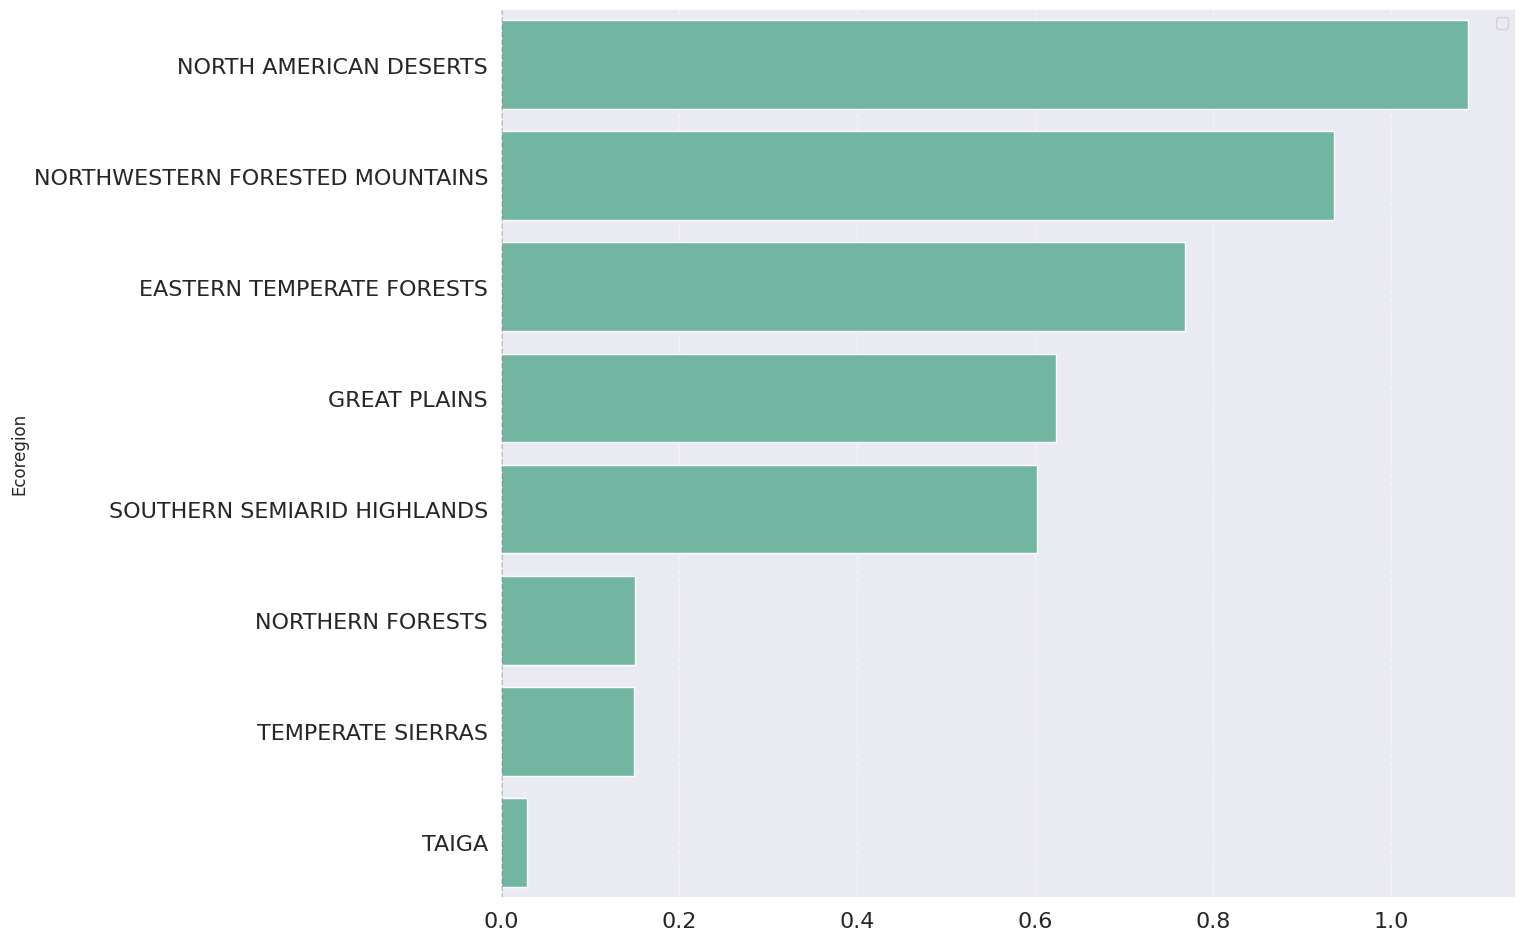

In [11]:
from lib.utils_plotting import plot_mae_improvement_by_region

results_mae_df_ = results_mae_df.copy()
plot_mae_improvement_by_region(
    results_mae_df_,
    geo_path=path_config.get_data_geojson(),
    eco_path="useco1/NA_CEC_Eco_Level1.shp",
    methods_to_compare=["Ensemble prithvi_pretrained_crops_cathls_conv3d_1.0, shallow_transformer_pixels_1.0"],
    anchor_method="shallow_transformer_pixels_1.0_test",
    figsize=(14, 10)
)